# 07 — Angular Cross-Power Spectra

The observable signal is $C_\ell^{\mathrm{HI}\times\gamma}$, computed via the
Limber approximation. At each comoving distance, the HI and gamma-ray window
functions weight the 3D cross-power spectrum. The 2-halo term factorizes into
bias-weighted integrals $\times$ $P_\mathrm{lin}$, enabling efficient computation.

**References:** `docs/equations.md` §9 (Eqs. 9.1–9.5); Pinetti+ (2020) Eq. 2.1.

In [7]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'hi_gamma_xcorr').is_dir():
            return candidate
    raise RuntimeError(f'Could not locate repo root from {start}')

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from hi_gamma_xcorr import config as cfg, cosmology as cosmo
from hi_gamma_xcorr import plotting as sty
cosmo.init()
print("Pipeline initialized.")

Pipeline initialized.


In [8]:
from hi_gamma_xcorr import halo_model as hm, hi_model as hi
from hi_gamma_xcorr import dm_model as dm, astro_sources as astro
from hi_gamma_xcorr import angular_power as ap

\
## 1. 3D Cross-Power Spectra (Eqs. 9.2–9.3)

$$P_{\mathrm{HI}\times\mathrm{astro}}^{2h} = I_\mathrm{HI}^{2h}\,b_\mathrm{astro}\,P_\mathrm{lin}$$

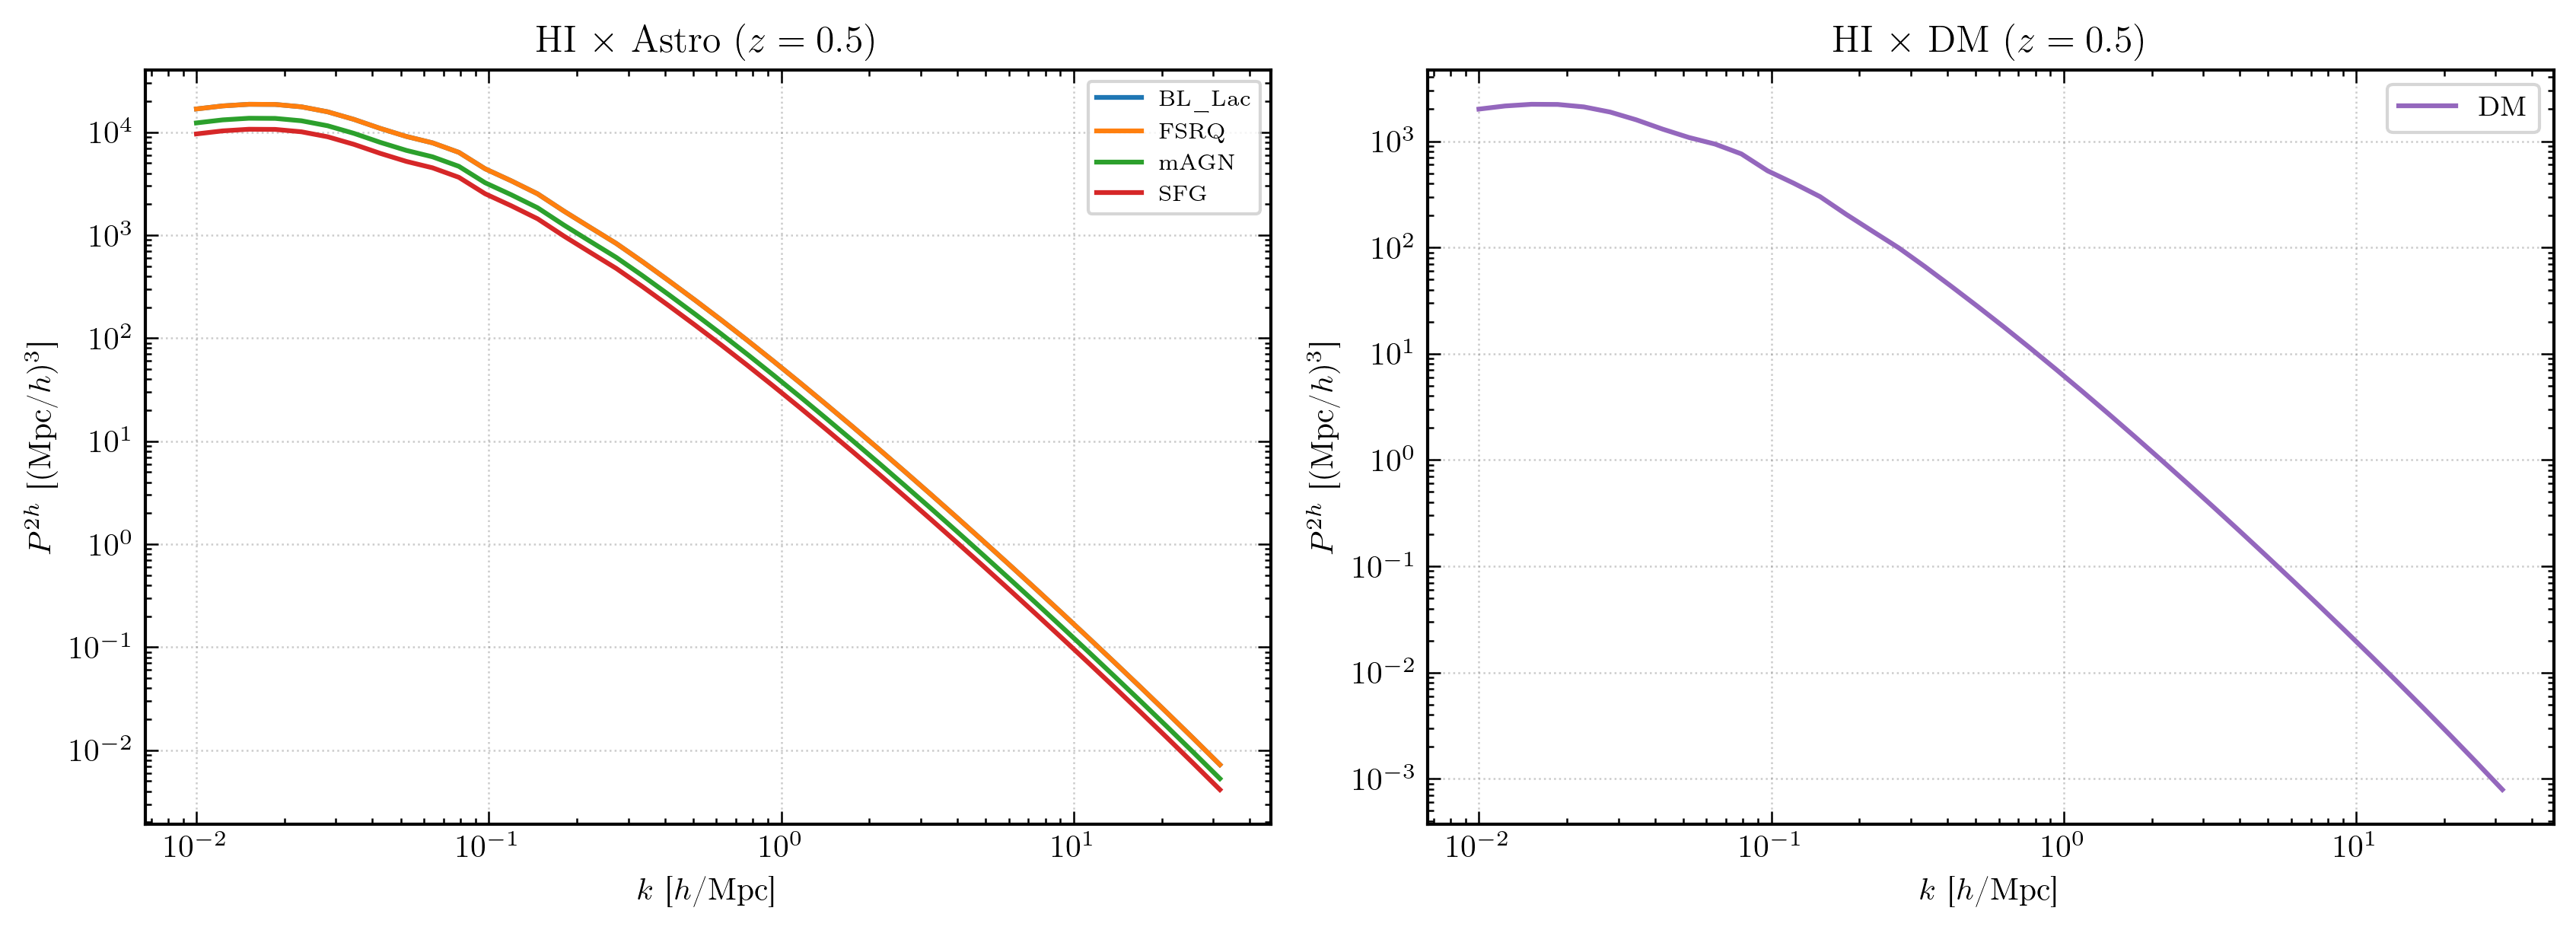

In [9]:
k_arr = np.logspace(-2, 1.5, 40)
z = 0.5
sources = ['BL_Lac', 'FSRQ', 'mAGN', 'SFG']
colors = {'BL_Lac': 'C0', 'FSRQ': 'C1', 'mAGN': 'C2', 'SFG': 'C3', 'DM': 'C4'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(sty.TEXTWIDTH_IN * 1.5, sty.TEXTWIDTH_IN * 0.55))
for src in sources:
    P = ap.P_HI_astro_2h(k_arr, z, src, n_M=30)
    ax1.loglog(k_arr, P, color=colors[src], lw=sty.LW_STANDARD, label=src)
ax1.set_xlabel(r'$k$ [$h$/Mpc]'); ax1.set_ylabel(r'$P^{2h}$ [(Mpc/$h$)$^3$]')
ax1.set_title(rf'HI $\times$ Astro ($z={z}$)'); ax1.legend(fontsize=sty.LEGEND_SIZE)

P_dm = ap.P_HI_DM_2h(k_arr, z, n_M=30)
ax2.loglog(k_arr, P_dm, color='C4', lw=sty.LW_STANDARD, label='DM')
ax2.set_xlabel(r'$k$ [$h$/Mpc]'); ax2.set_ylabel(r'$P^{2h}$ [(Mpc/$h$)$^3$]')
ax2.set_title(rf'HI $\times$ DM ($z={z}$)'); ax2.legend()
fig.tight_layout()

## 2. Angular Power Spectrum $C_\ell$ Decomposed by Source (Eq. 9.4)

$$C_\ell = \int\frac{d\chi}{\chi^2}\,W_\mathrm{HI}\,W_\gamma\,
P_\mathrm{cross}\!\left(k=\frac{\ell+\tfrac12}{\chi},\,z\right)$$

Uses the half-integer Limber substitution $k = (\ell + \tfrac{1}{2})/\chi$
(**D8**: thesis uses $k = \ell/\chi$).

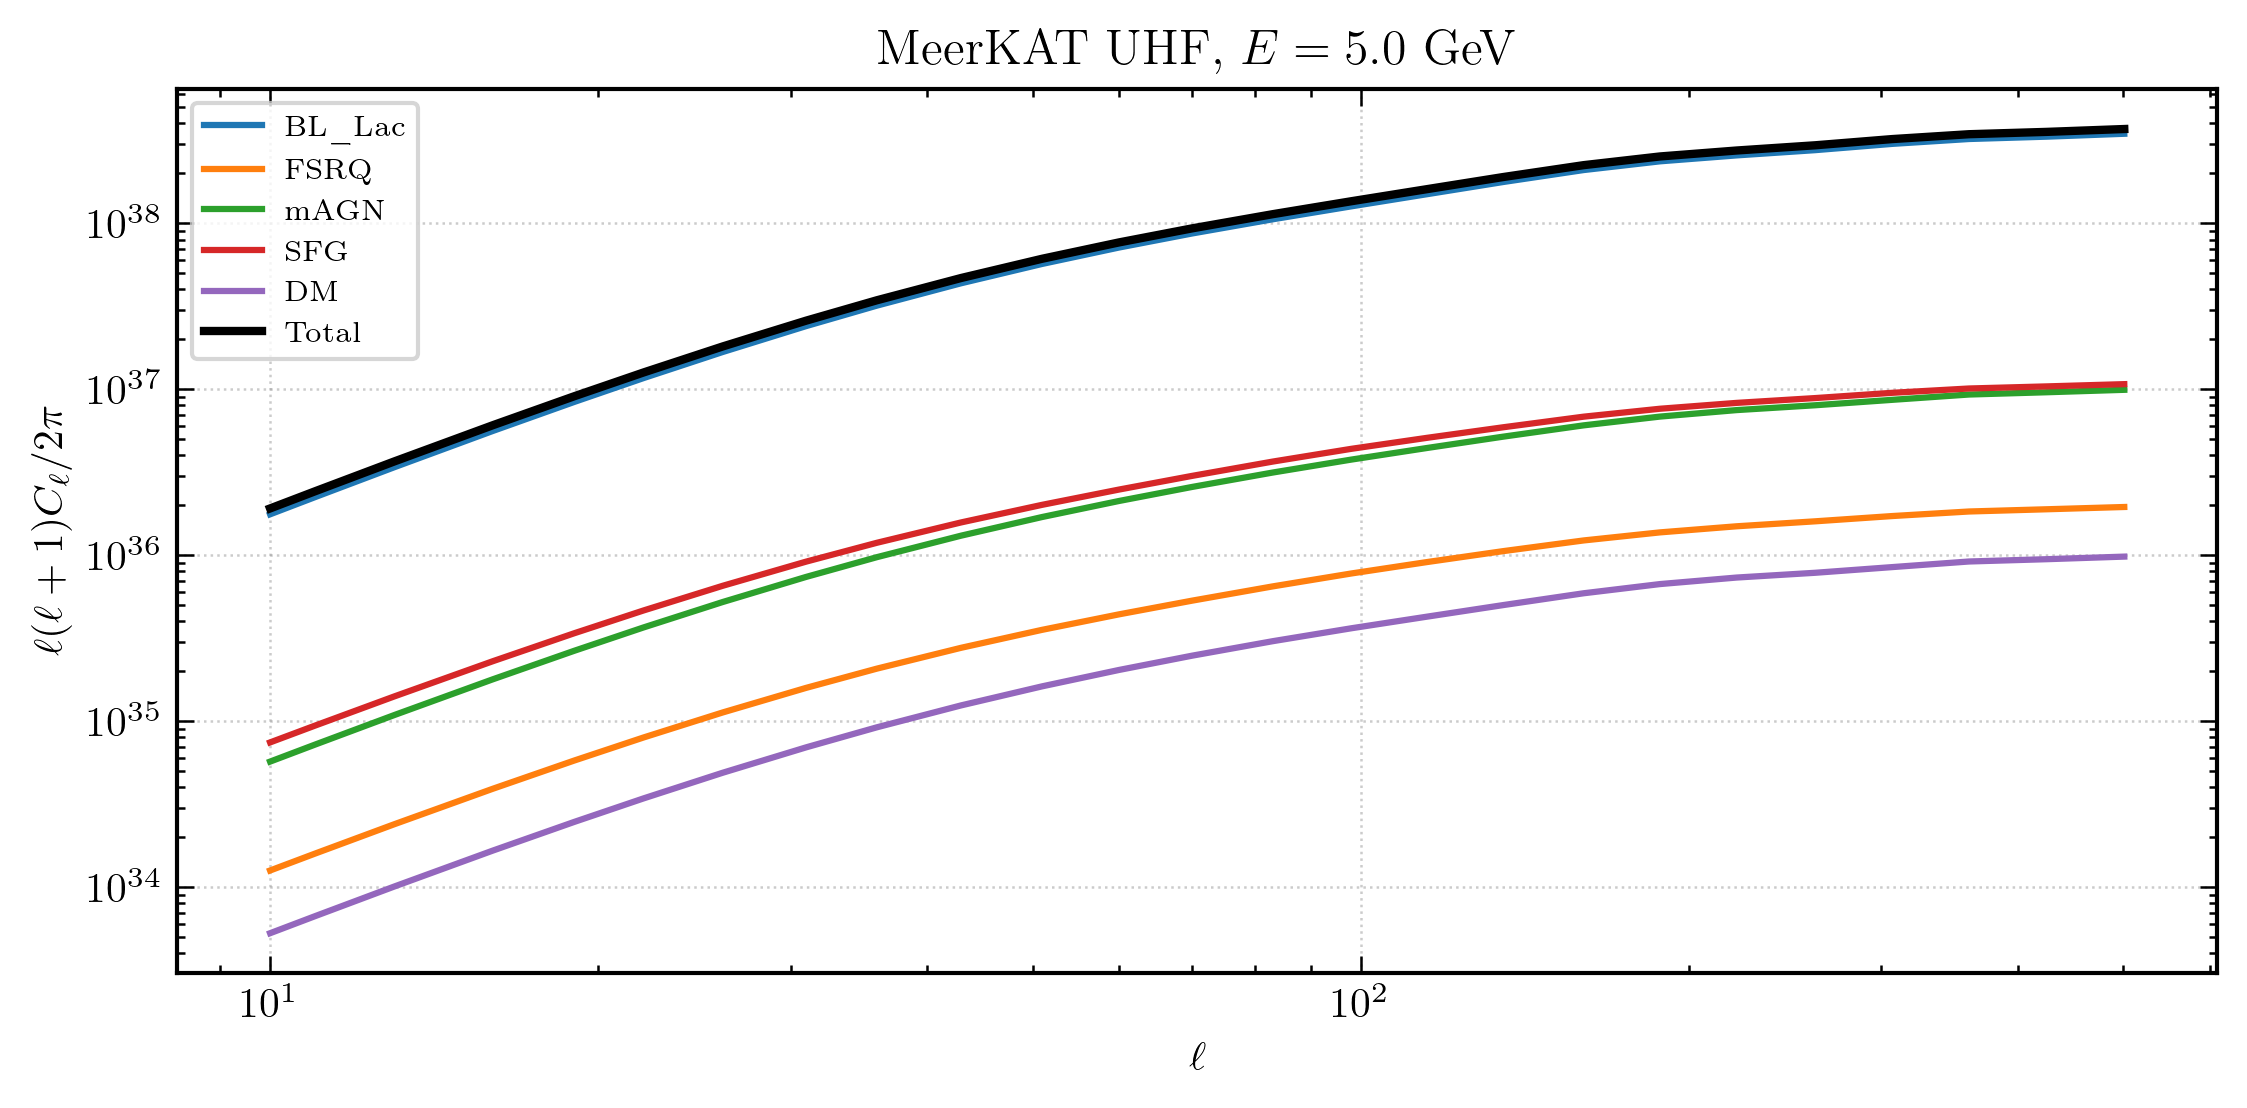

In [10]:
telescope, band, E_GeV = 'MeerKAT', 'UHF', 5.0
tel = cfg.RADIO_TELESCOPES[telescope]
z_min, z_max = tel['bands'][band]['z_min'], tel['bands'][band]['z_max']
ell = np.unique(np.logspace(1, 2.7, 25).astype(int)).astype(float)

result = ap.C_ell_HI_gamma(ell, E_GeV, z_min, z_max, telescope, band,
                           n_z=80, n_k_M=15)

fig, ax = sty.textwidth_figure(8)
for key in ['BL_Lac', 'FSRQ', 'mAGN', 'SFG', 'DM']:
    if key in result:
        C = result[key]; nz = np.abs(C) > 0
        if np.any(nz):
            ax.loglog(ell[nz], ell[nz]*(ell[nz]+1)*np.abs(C[nz])/(2*np.pi),
                      color=colors.get(key), lw=sty.LW_STANDARD, label=key)
C_tot = result['total']; nz = np.abs(C_tot) > 0
ax.loglog(ell[nz], ell[nz]*(ell[nz]+1)*np.abs(C_tot[nz])/(2*np.pi),
          'k-', lw=sty.LW_MEDIUM, label='Total')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi$')
ax.set_title(f'{telescope} {band}, $E = {E_GeV}$ GeV')
ax.legend(fontsize=sty.LEGEND_SIZE); fig.tight_layout()

## 3. Normalized Window Functions

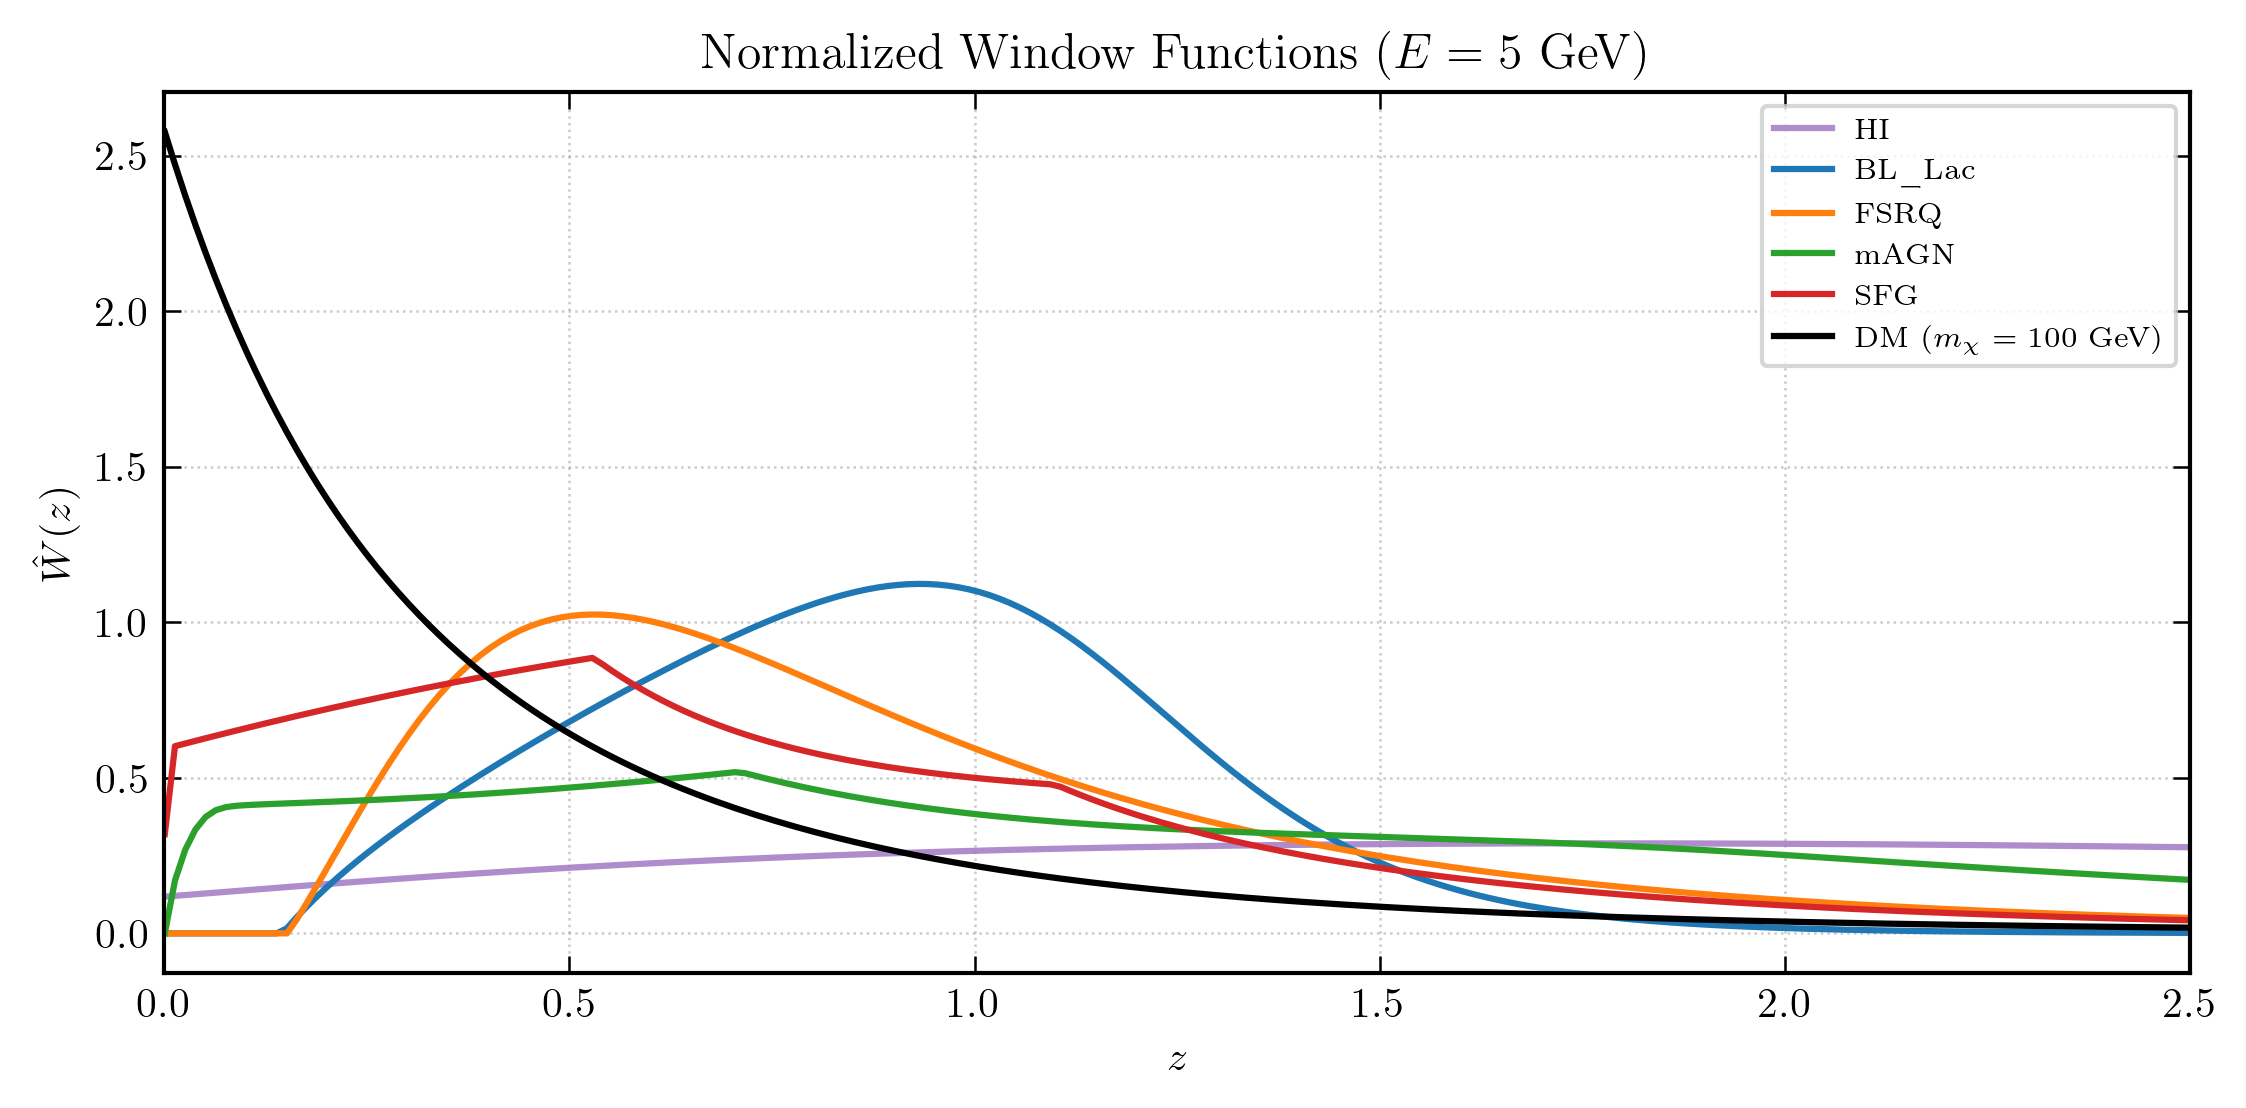

In [11]:
z_plot = np.linspace(0.001, 2.5, 200)
W_norm = ap.normalized_windows(z_plot, E_GeV=5.0, unresolved_only=True, include_DM=True)

fig, ax = sty.textwidth_figure(8)
ax.plot(z_plot, W_norm['HI'], 'C4', **sty.FIT_STYLE, label='HI')
for src in sources:
    ax.plot(z_plot, W_norm[src], color=colors[src], lw=sty.LW_STANDARD, label=src)
ax.plot(z_plot, W_norm['DM'], 'k', lw=sty.LW_STANDARD, label=r'DM ($m_\chi=100$ GeV)')
ax.set_xlabel('$z$'); ax.set_ylabel(r'$\hat{W}(z)$')
ax.set_title('Normalized Window Functions ($E = 5$ GeV)')
ax.legend(fontsize=sty.LEGEND_SIZE); ax.set_xlim(0, 2.5); fig.tight_layout()

## 4. HI Brightness Mode Comparison (**D15**)

The Cunnington+2025 mode switches both brightness ($180$ mK prefactor,
polynomial $\Omega_\mathrm{HI}$) and bias ($b_\mathrm{HI}^\mathrm{cunn}$
polynomial, $P_\mathrm{HI}^\mathrm{2h} = b^2 P_\mathrm{lin}$).

In [ ]:
fig, ax = sty.textwidth_figure(8)
for mode, style in [('cunnington', sty.FIT_STYLE), ('padmanabhan', sty.DASHDOT_STYLE),
                     ('fixed_omega', sty.MODEL_STYLE)]:
    r = ap.C_ell_HI_gamma(ell, E_GeV, z_min, z_max, telescope, band,
                          n_z=80, n_k_M=15, hi_brightness=mode)
    C = r['total']; nz = np.abs(C) > 0
    if np.any(nz):
        ax.loglog(ell[nz], ell[nz]*(ell[nz]+1)*np.abs(C[nz])/(2*np.pi),
                  **style, label=mode)
ax.set_xlabel(r'$\ell$'); ax.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi$')
ax.set_title(r'Total $C_\ell$: HI Brightness Modes'); ax.legend(); fig.tight_layout()